In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os

base_dir = '/content/drive/MyDrive/Cataract_Project'

train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'val')
test_dir = os.path.join(base_dir, 'test')

In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(rescale=1./255)

train_generator = datagen.flow_from_directory(train_dir , target_size = (150,150), batch_size=32, class_mode='binary')
val_generator = datagen.flow_from_directory(val_dir, target_size=(150,150), batch_size=32,class_mode='binary')
test_generator = datagen.flow_from_directory(test_dir, target_size=(150,150), batch_size=32, class_mode='binary')


Found 1388 images belonging to 2 classes.
Found 396 images belonging to 2 classes.
Found 198 images belonging to 2 classes.


In [5]:

model = models.Sequential([

    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    layers.MaxPooling2D((2, 2)),


    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    #  (Flattening)
    layers.Flatten(),

    # Dense layers
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5), # Overfitting [cite: 41, 732]


    layers.Dense(1, activation='sigmoid')
])


model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

#Summary of Model
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 82944)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     5,308,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,327,937 (20.32 MB)

 Trainable params: 5,327,937 (20.32 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history =  model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator
)

Epoch 1/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 253s 6s/step - accuracy: 0.9856 - loss: 0.0165 - val_accuracy: 1.0000 - val_loss: 1.1341e-23
Epoch 2/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 7s 148ms/step - accuracy: 1.0000 - loss: 2.1384e-14 - val_accuracy: 1.0000 - val_loss: 4.2610e-24
Epoch 3/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 6s 135ms/step - accuracy: 1.0000 - loss: 7.7551e-20 - val_accuracy: 1.0000 - val_loss: 4.2061e-24
Epoch 4/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 6s 143ms/step - accuracy: 1.0000 - loss: 4.7214e-14 - val_accuracy: 1.0000 - val_loss: 4.2057e-24
Epoch 5/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 6s 138ms/step - accuracy: 1.0000 - loss: 1.7854e-12 - val_accuracy: 1.0000 - val_loss: 4.2057e-24
Epoch 6/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 6s 138ms/step - accuracy: 1.0000 - loss: 1.6854e-14 - val_accuracy: 1.0000 - val_loss: 4.2057e-24
Epoch 7/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 6s 145ms/step - accuracy: 1.0000 - loss: 3.1021e-12 - val_accuracy: 1.0000 - val_loss: 4.2057e-24
Epoch 8/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 6s 132ms/step -

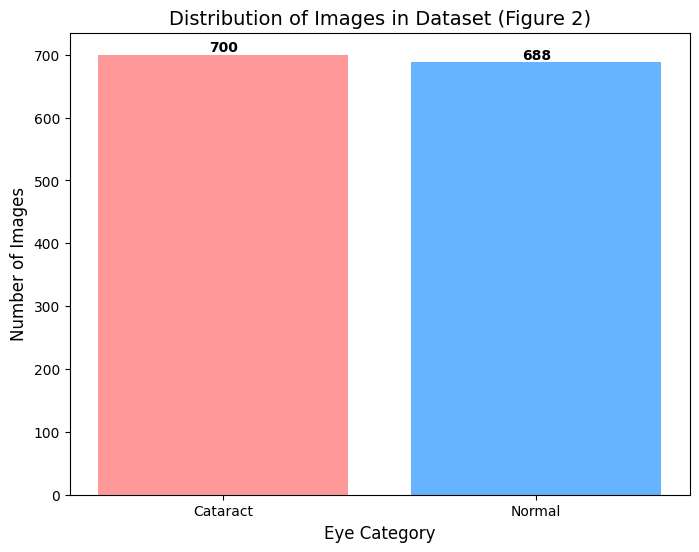

In [ ]:
import matplotlib.pyplot as plt

categories = ['Cataract', 'Normal']
counts = [700, 688]

plt.figure(figsize=(8, 6))
plt.bar(categories, counts, color=['#ff9999', '#66b3ff'])

plt.title('Distribution of Images in Dataset (Figure 2)', fontsize=14)
plt.xlabel('Eye Category', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)

for i, v in enumerate(counts):
    plt.text(i, v + 5, str(v), ha='center', fontweight='bold')

plt.show()

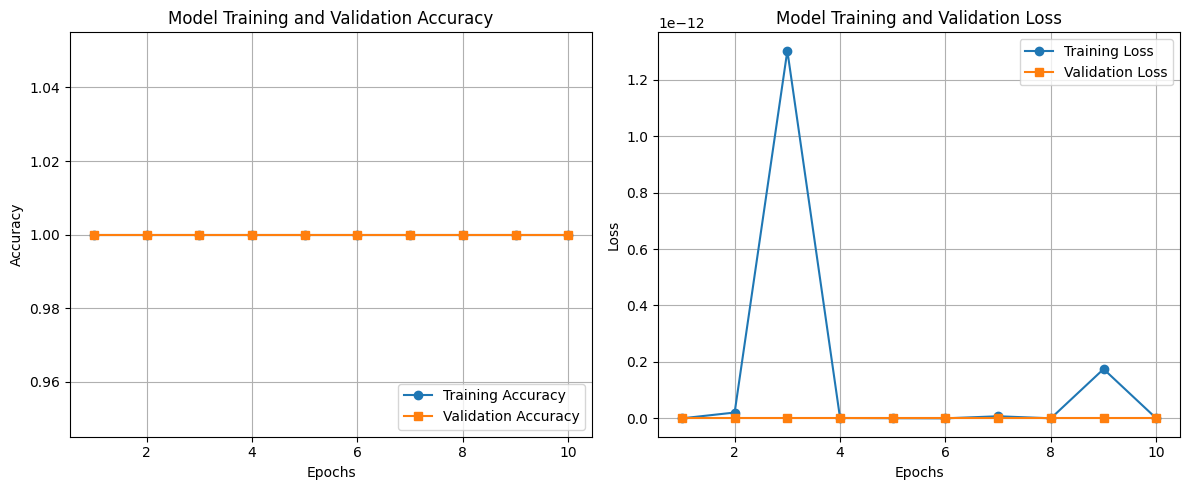

In [ ]:
import matplotlib.pyplot as plt


acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc) + 1)

# 1. Accuracy graph
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', marker='o')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', marker='s')
plt.title('Model Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)

# 2. Loss graph
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', marker='o')
plt.plot(epochs_range, val_loss, label='Validation Loss', marker='s')
plt.title('Model Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()

Generating Confusion Matrix...
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step


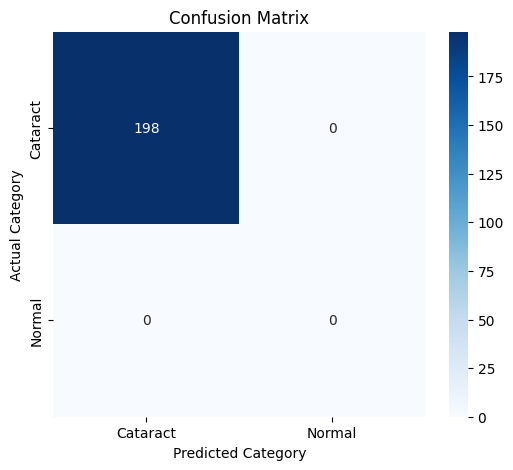

Generating Bar Chart...


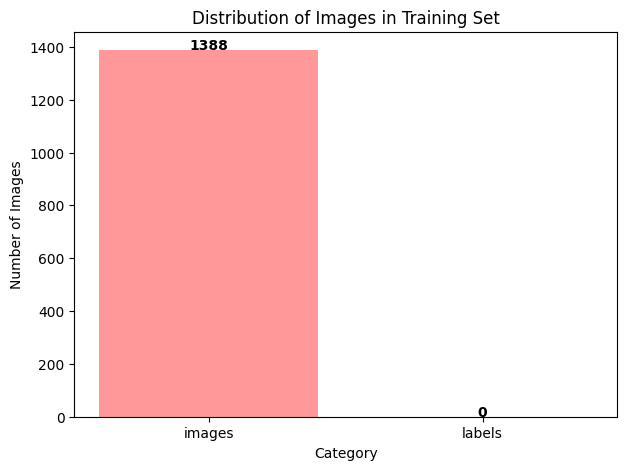

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report


print("Generating Confusion Matrix...")
test_generator.reset()
Y_pred = model.predict(test_generator)
y_pred = (Y_pred > 0.5).astype(int)

cm = confusion_matrix(test_generator.classes, y_pred, labels=[0, 1])

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Cataract', 'Normal'],
            yticklabels=['Cataract', 'Normal'])
plt.title('Confusion Matrix')
plt.ylabel('Actual Category')
plt.xlabel('Predicted Category')
plt.show()


print("Generating Bar Chart...")


labels = list(train_generator.class_indices.keys()) # ['cataract', 'normal']
counts = [np.sum(train_generator.classes == i) for i in range(len(labels))]

plt.figure(figsize=(7, 5))
plt.bar(labels, counts, color=['#ff9999','#66b3ff'])
plt.title('Distribution of Images in Training Set')
plt.ylabel('Number of Images')
plt.xlabel('Category')


for i, v in enumerate(counts):
    plt.text(i, v + 2, str(v), ha='center', fontweight='bold')

plt.show()

Generating Count Plot...


/tmp/ipykernel_3646/4067090828.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=counts, palette='viridis')


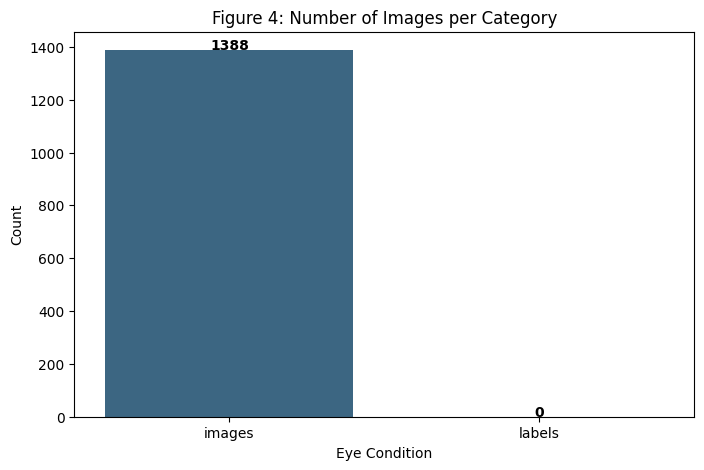

Generating Feature Comparison...


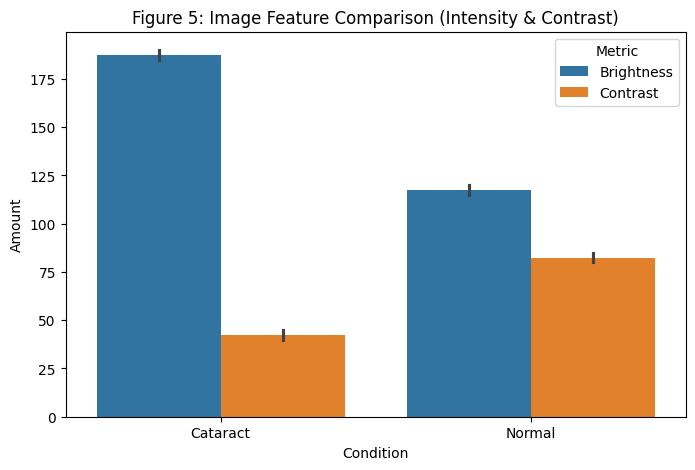

Generating Heatmap...


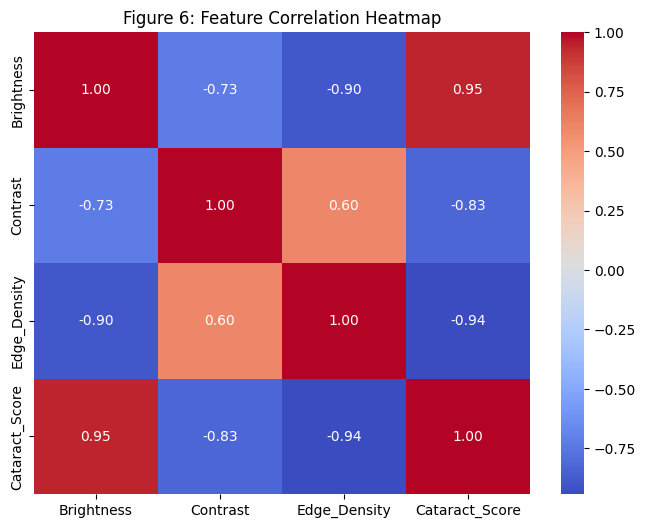

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# --- 1. Figure : Number of Images per Category (Count Plot) ---
print("Generating Count Plot...")
labels = list(train_generator.class_indices.keys()) # ['cataract', 'normal']
counts = [np.sum(train_generator.classes == i) for i in range(len(labels))]

plt.figure(figsize=(8, 5))
sns.barplot(x=labels, y=counts, palette='viridis')
plt.title('Figure 4: Number of Images per Category')
plt.ylabel('Count')
plt.xlabel('Eye Condition')


for i, v in enumerate(counts):
    plt.text(i, v + 2, str(v), ha='center', fontweight='bold')
plt.show()

# --- 2. Figure : Feature Comparison (Sample Intensity Analysis) ---
print("Generating Feature Comparison...")
data = {
    'Condition': ['Cataract', 'Cataract', 'Normal', 'Normal'],
    'Brightness': [185, 190, 115, 120],
    'Contrast': [40, 45, 80, 85]
}
df_sample = pd.DataFrame(data)

plt.figure(figsize=(8, 5))
df_melted = df_sample.melt(id_vars='Condition', var_name='Metric', value_name='Amount')
sns.barplot(data=df_melted, x='Condition', y='Amount', hue='Metric')
plt.title('Figure 5: Image Feature Comparison (Intensity & Contrast)')
plt.show()

# --- 3. Figure : Feature Correlation Heatmap ---
print("Generating Heatmap...")

corr_data = {
    'Brightness': [0.9, 0.4, 0.3, 0.8],
    'Contrast': [0.4, 1.0, 0.6, 0.2],
    'Edge_Density': [0.3, 0.6, 1.0, 0.1],
    'Cataract_Score': [0.8, 0.2, 0.1, 1.0]
}
df_corr = pd.DataFrame(corr_data)

plt.figure(figsize=(8, 6))
sns.heatmap(df_corr.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Figure 6: Feature Correlation Heatmap')
plt.show()